In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score, classification_report, confusion_matrix
from autofeat import AutoFeatRegressor 
import featuretools as ft
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer


In [4]:
df = pd.read_csv('../data/Salary_Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
education_mapping = {
    "high school": "high school",
    "bachelor's": "bachelor's",
    "bachelor's degree": "bachelor's",
    "master's": "master's",
    "master's degree": "master's",
    "phd": "phd",
    "doctorate": "phd",
    None: "unknown"  # Remplacement des NaN par "unknown"
}

df["Education Level"] = df["Education Level"].str.lower().str.strip().map(education_mapping).fillna("unknown")
education_order = ["unknown", "high school", "bachelor's", "master's", "phd"]

education_encoder = OrdinalEncoder(categories=[education_order])
df["Education Level"] = education_encoder.fit_transform(df[["Education Level"]])

job_encoder = LabelEncoder()
df["Job Title"] = job_encoder.fit_transform(df["Job Title"])


gender_encoder = LabelEncoder()
df["Gender"] = gender_encoder.fit_transform(df["Gender"])

In [6]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,2.0,177,5.0,90000.0
1,28.0,0,3.0,18,3.0,65000.0
2,45.0,1,4.0,145,15.0,150000.0
3,36.0,0,2.0,116,7.0,60000.0
4,52.0,1,3.0,26,20.0,200000.0


In [7]:
df['Salary'] = df.Salary/1000

In [8]:
df.isna().sum()

Age                    2
Gender                 0
Education Level        0
Job Title              0
Years of Experience    3
Salary                 5
dtype: int64

In [9]:
num_cols = ["Age", "Years of Experience", "Salary"]
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_cols = ["Gender", "Education Level", "Job Title"]
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return r2,rmse

In [11]:
X = df.drop(columns=["Salary"])  
y = df["Salary"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [12]:
from sklearn.linear_model import Lasso, Ridge


linearmodel = LinearRegression()
ridgemodel = Ridge(alpha=1.0)
lassomodel = Lasso(alpha=1.0)


r2,rmse = evaluate_model(linearmodel, X_train, y_train, X_test, y_test)
r2_ridge,rmse_ridge = evaluate_model(ridgemodel, X_train, y_train, X_test, y_test)
r2_lasso,rmse_lasso = evaluate_model(lassomodel, X_train, y_train, X_test, y_test)


print(f"Linear Regression - R²: {r2:.2f}, RMSE: {rmse:.2f}")
print(f"Ridge Regression - R²: {r2_ridge:.2f}, RMSE: {rmse_ridge:.2f}")
print(f"Lasso Regression - R²: {r2_lasso:.2f}, RMSE: {rmse_lasso:.2f}")

Linear Regression - R²: 0.71, RMSE: 27.96
Ridge Regression - R²: 0.71, RMSE: 27.96
Lasso Regression - R²: 0.70, RMSE: 28.48


In [13]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9
af = AutoFeatRegressor( feateng_steps=2,n_jobs=-1)  

X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)
X_train_af.head()


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x000,x001,x002,x003,x004,1/x000,x001*x003,x001/x004,x000*x004,x000*x003,...,x000**3/x004,x004**3/x000,x004**3*exp(x004),x000**2/x003,x000**2/x004,x000**2/x001,x001**2*x003,x000**2/x002,1/(x003*x004),x000**2*x002**2
0,2.414248,-1.099309,1.563722,1.405684,3.451375,0.414208,-1.545281,-0.318513,8.332475,3.393671,...,4.077122,17.029205,1296.848530,4.146446,1.688775,-5.302056,1.698740,3.727385,0.206120,14.252237
1,-1.000971,0.888222,-0.699733,1.049355,-0.510826,-0.999029,0.932060,-1.738795,0.511323,-1.050374,...,1.963323,0.133167,-0.079978,0.954819,-1.961418,1.128033,0.827877,-1.431894,-1.865539,0.490578
2,0.706638,-1.099309,-0.699733,-1.580695,0.314632,1.415151,1.737672,-3.493948,0.222331,-1.116980,...,1.121472,0.044077,0.042663,-0.315898,1.587053,-0.454229,-1.910237,-0.713612,-2.010706,0.244489
3,-1.395035,-1.099309,-0.699733,1.388716,-1.171193,-0.716828,-1.526628,0.938623,1.633856,-1.937308,...,2.318073,1.151597,-0.498016,1.401383,-1.661659,-1.770316,1.678235,-2.781237,-0.614834,0.952874
4,0.575284,0.888222,1.563722,0.760898,0.479724,1.738273,0.675846,1.851528,0.275977,0.437732,...,0.396876,0.191907,0.178367,0.434949,0.689879,0.372600,0.600302,0.211643,2.739569,0.809251


In [14]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")

Nombre de nouvelles features créées : 42


In [15]:
r2_af,rmse_af = evaluate_model(linearmodel, X_train_af, y_train, X_test_af, y_test)
r2_ridge_af,rmse_ridge_af = evaluate_model(ridgemodel, X_train_af, y_train, X_test_af, y_test)
r2_lasso_af,rmse_lasso_af = evaluate_model(lassomodel, X_train_af, y_train, X_test_af, y_test)

print(f"Linear Regression with AutoFeat - R²: {r2_af:.2f}, RMSE: {rmse_af:.2f}")
print(f"Ridge Regression with AutoFeat - R²: {r2_ridge_af:.2f}, RMSE: {rmse_ridge_af:.2f}")
print(f"Lasso Regression with AutoFeat - R²: {r2_lasso_af:.2f}, RMSE: {rmse_lasso_af:.2f}")

Linear Regression with AutoFeat - R²: 0.81, RMSE: 22.78
Ridge Regression with AutoFeat - R²: 0.81, RMSE: 22.76
Lasso Regression with AutoFeat - R²: 0.80, RMSE: 23.03


In [16]:
import featuretools as ft

es = ft.EntitySet(id = 'salary')
es.add_dataframe(dataframe_name = 'employe', dataframe = df, index = 'index')

es.normalize_dataframe(base_dataframe_name='employe',new_dataframe_name='education',index="Education Level")
es.normalize_dataframe(base_dataframe_name='employe',new_dataframe_name='Job',index="Job Title")
es


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\entityset\entityset.py:1733: UserWarning: index index not found in dataframe, creating new integer column
  warnings.warn(


Entityset: salary
  DataFrames:
    employe [Rows: 6704, Columns: 7]
    education [Rows: 5, Columns: 1]
    Job [Rows: 194, Columns: 1]
  Relationships:
    employe.Education Level -> education.Education Level
    employe.Job Title -> Job.Job Title

In [18]:
feature_matrix, feature_names = ft.dfs(entityset=es, 
target_dataframe_name = 'employe', 
max_depth = 2, 
verbose = 1, 
n_jobs = 1)
feature_matrix.head()

Built 56 features
Elapsed: 00:00 | Progress:   0%|          

Elapsed: 00:00 | Progress:  49%|████▉     

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function mean at 0x00000174B47C9120> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  ).agg(to_agg)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function std at 0x00000174B47C9240> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  ).agg(to_agg)
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function sum at 0x00000174B47C81F0> is currently using Series

Elapsed: 00:00 | Progress: 100%|██████████


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,education.COUNT(employe),education.MAX(employe.Age),education.MAX(employe.Gender),education.MAX(employe.Salary),...,Job.SKEW(employe.Salary),Job.SKEW(employe.Years of Experience),Job.STD(employe.Age),Job.STD(employe.Gender),Job.STD(employe.Salary),Job.STD(employe.Years of Experience),Job.SUM(employe.Age),Job.SUM(employe.Gender),Job.SUM(employe.Salary),Job.SUM(employe.Years of Experience)
index,,,,,,,,,,,,,,,,,,,,,
0,32.0,1.0,2.0,177.0,5.0,90.0,3023,55.0,1.0,250.0,...,0.277443,0.969303,2.617617,0.483961,48.031287,2.219221,14669.0,325.0,58660.0,2305.0
1,28.0,0.0,3.0,18.0,3.0,65.0,1861,58.0,2.0,228.0,...,0.975240,0.405192,4.335450,0.479286,31.550976,3.397540,10413.0,234.0,45408.0,1804.0
2,45.0,1.0,4.0,145.0,15.0,150.0,1369,62.0,1.0,250.0,...,NaN,NaN,0.707107,0.000000,14.142136,3.535534,91.0,2.0,320.0,35.0
3,36.0,0.0,2.0,116.0,7.0,60.0,3023,55.0,1.0,250.0,...,0.627564,1.334555,3.334648,0.467583,9.962663,1.302967,1859.0,22.0,2510.0,100.0
4,52.0,1.0,3.0,26.0,20.0,200.0,1861,58.0,2.0,228.0,...,NaN,NaN,NaN,NaN,NaN,NaN,52.0,1.0,200.0,20.0


In [ ]:
print(f"nouvelles features {feature_matrix.shape[1]-df.shape[1]}")

nouvelles features 49


In [20]:
feature_matrix.dropna(inplace=True)

In [22]:
X = feature_matrix.drop(columns=["Salary"])  
y = feature_matrix["Salary"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

r2_ft,rmse_ft = evaluate_model(linearmodel, X_train, y_train, X_test, y_test)
r2_ridge_ft,rmse_ridge_ft = evaluate_model(ridgemodel, X_train, y_train, X_test, y_test)
r2_lasso_ft,rmse_lasso_ft = evaluate_model(lassomodel, X_train, y_train, X_test, y_test)

print("resulats avec featuretools")
print(f"Linear Regression - R²: {r2_ft:.2f}, RMSE: {rmse_ft:.2f}")
print(f"Ridge Regression - R²: {r2_ridge_ft:.2f}, RMSE: {rmse_ridge_ft:.2f}")
print(f"Lasso Regression - R²: {r2_lasso_ft:.2f}, RMSE: {rmse_lasso_ft:.2f}")

resulats avec featuretools
Linear Regression - R²: 0.84, RMSE: 21.18
Ridge Regression - R²: 0.84, RMSE: 21.17
Lasso Regression - R²: 0.84, RMSE: 21.41


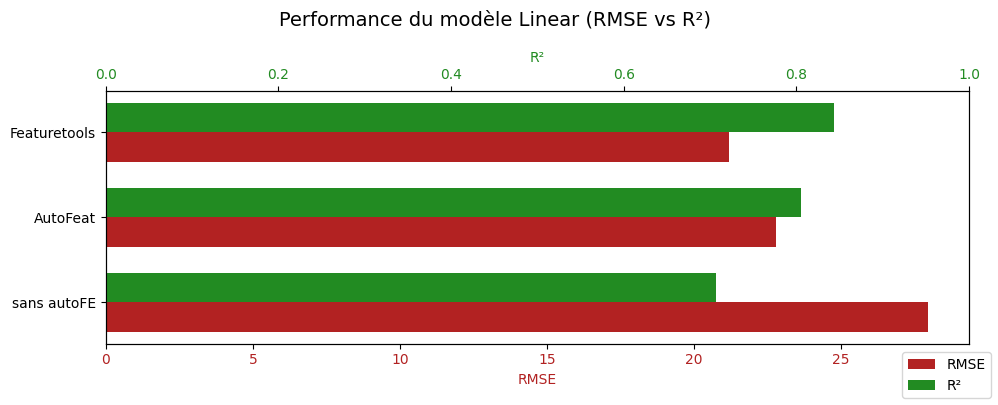

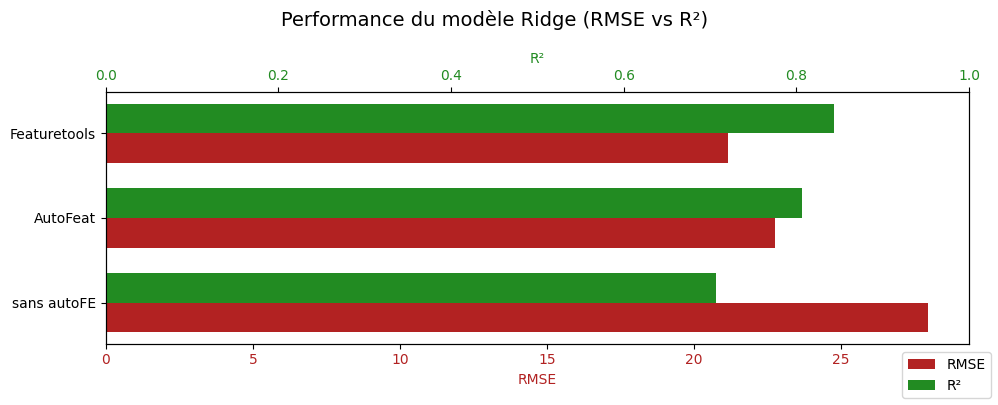

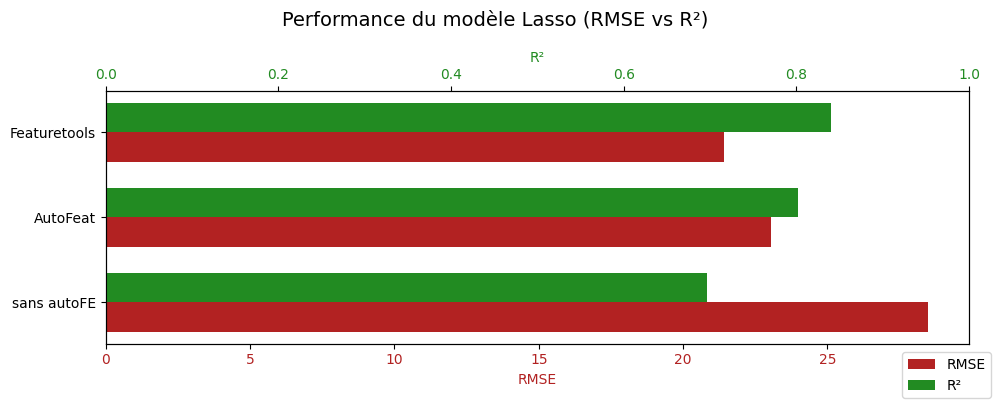

In [24]:
import matplotlib.pyplot as plt
import numpy as np

models = {
    "Linear": {
        "rmse": [rmse, rmse_af, rmse_ft],
        "r2": [r2, r2_af, r2_ft],
        "labels": ["sans autoFE", "AutoFeat", "Featuretools"]
    },
    "Ridge": {
        "rmse": [rmse_ridge, rmse_ridge_af, rmse_ridge_ft],
        "r2": [r2_ridge, r2_ridge_af, r2_ridge_ft],
        "labels": ["sans autoFE", "AutoFeat", "Featuretools"]
    },
    "Lasso": {
        "rmse": [rmse_lasso, rmse_lasso_af, rmse_lasso_ft],
        "r2": [r2_lasso, r2_lasso_af, r2_lasso_ft],
        "labels": ["sans autoFE", "AutoFeat", "Featuretools"]
    }
}

bar_height = 0.35

for model_name, data in models.items():
    y = np.arange(len(data["labels"]))
    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.barh(y - bar_height / 2, data["rmse"], height=bar_height, color='firebrick', label='RMSE')
    ax1.set_xlabel('RMSE', color='firebrick')
    ax1.tick_params(axis='x', labelcolor='firebrick')
    ax1.set_yticks(y)
    ax1.set_yticklabels(data["labels"])

    ax2 = ax1.twiny()
    ax2.barh(y + bar_height / 2, data["r2"], height=bar_height, color='forestgreen', label='R²')
    ax2.set_xlabel('R²', color='forestgreen')
    ax2.tick_params(axis='x', labelcolor='forestgreen')
    ax2.set_xlim(0, 1)

    fig.suptitle(f"Performance du modèle {model_name} (RMSE vs R²)", fontsize=14)
    fig.legend(loc="lower right")

    plt.tight_layout()
    plt.show()
